# Prophet Playground

Interactive environment to step through the `prophet_model.py` pipeline for Retail Forecasting.

In [18]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is in path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Import specialized Prophet functions
from src.models.prophet_model import (
    load_processed_data, 
    preprocess_and_split, 
    train_models, 
    predict_models, 
    evaluate_models,
    save_prophet_artifacts
)
from src.tools import plot_cluster_portfolio, analyze_time_periods, plot_mape_vs_volume

print("Setup complete. Local prophet modules loaded from src/.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup complete. Local prophet modules loaded from src/.


## 1. Global Data Loading

We load the global processed dataset once. It contains all features, including the raw consumption and weather signals that will be scaled differently depending on the forecast mode.

In [19]:
data_path = os.path.join(PROJECT_ROOT, 'data', 'processed_retail_data.parquet')
df_long = pd.read_parquet(data_path)
df_long.head()

,StockCode,Week,Quantity,Revenue,week_of_year,month,quarter,year,sin_woy,cos_woy,...,volume_tier,semantic_cluster_name,ADI,CV2,demand_class,share_zero_weeks,price_median,mean_basket_size,n_unique_customers,country_uk_share
0,10080,2009-11-30,4,3.4,49,11,4,2009,-3.546049e-01,0.935016,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
1,10080,2009-12-07,0,0.0,50,12,4,2009,-2.393157e-01,0.970942,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
2,10080,2009-12-14,0,0.0,51,12,4,2009,-1.205367e-01,0.992709,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
3,10080,2009-12-21,0,0.0,52,12,4,2009,6.432491e-16,1.000000,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
4,10080,2009-12-28,0,0.0,53,12,4,2009,1.205367e-01,0.992709,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0


## 2. Preprocess & Split
Scales the continuous features (MinMaxScaler) per StockCode and drops unnecessary columns.

In [20]:
train_agg, test_agg, test_raw, regressors = preprocess_and_split(df_long)
print(f'Train shape: {train_agg.shape}')
print(f'Test shape: {test_agg.shape}')

Preparing train/test split and log-scaling...
Applying log1p scaling to Quantity...
Aggregating data and regressors by Cluster for Prophet training...
Train shape: (368, 8)
Test shape: (56, 8)


## 3. Train Models per Seasonal Profile

In [21]:
cluster_models = train_models(train_agg, regressors)

Training Prophet models for 4 clusters...


Training:   0%|          | 0/4 [00:00<?, ?it/s]22:18:01 - cmdstanpy - INFO - Chain [1] start processing
22:18:01 - cmdstanpy - INFO - Chain [1] done processing
Training:  25%|██▌       | 1/4 [00:00<00:00,  4.89it/s]22:18:01 - cmdstanpy - INFO - Chain [1] start processing
22:18:01 - cmdstanpy - INFO - Chain [1] done processing
Training:  50%|█████     | 2/4 [00:00<00:00,  4.00it/s]22:18:01 - cmdstanpy - INFO - Chain [1] start processing
22:18:01 - cmdstanpy - INFO - Chain [1] done processing
Training:  75%|███████▌  | 3/4 [00:00<00:00,  3.81it/s]22:18:01 - cmdstanpy - INFO - Chain [1] start processing
22:18:01 - cmdstanpy - INFO - Chain [1] done processing
Training: 100%|██████████| 4/4 [00:00<00:00,  4.44it/s]


## 4. Predict on Test Set

In [22]:
test_raw = predict_models(cluster_models, test_agg, test_raw, regressors)

Generating forecasts and un-scaling to raw Quantity...
Inverse transforming predictions (expm1)...


## 5. Evaluate

In [23]:
cluster_eval, summary = evaluate_models(test_raw)
display(summary)


Evaluating Portfolio Performance...


,WMAPE,Median_MAPE,Mean_Absolute_Error
Cluster,,,
Global,95.67,83.43,51.96
0,100.35,81.44,15.78
1,95.31,84.96,61.10
2,96.47,84.20,67.83
3,94.49,82.31,50.12


## 6. Visualization

/Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/src/tools/visualization.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sku_stats = c_data.groupby("StockCode", observed=True).apply(
/Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/src/tools/visualization.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sku_stats 

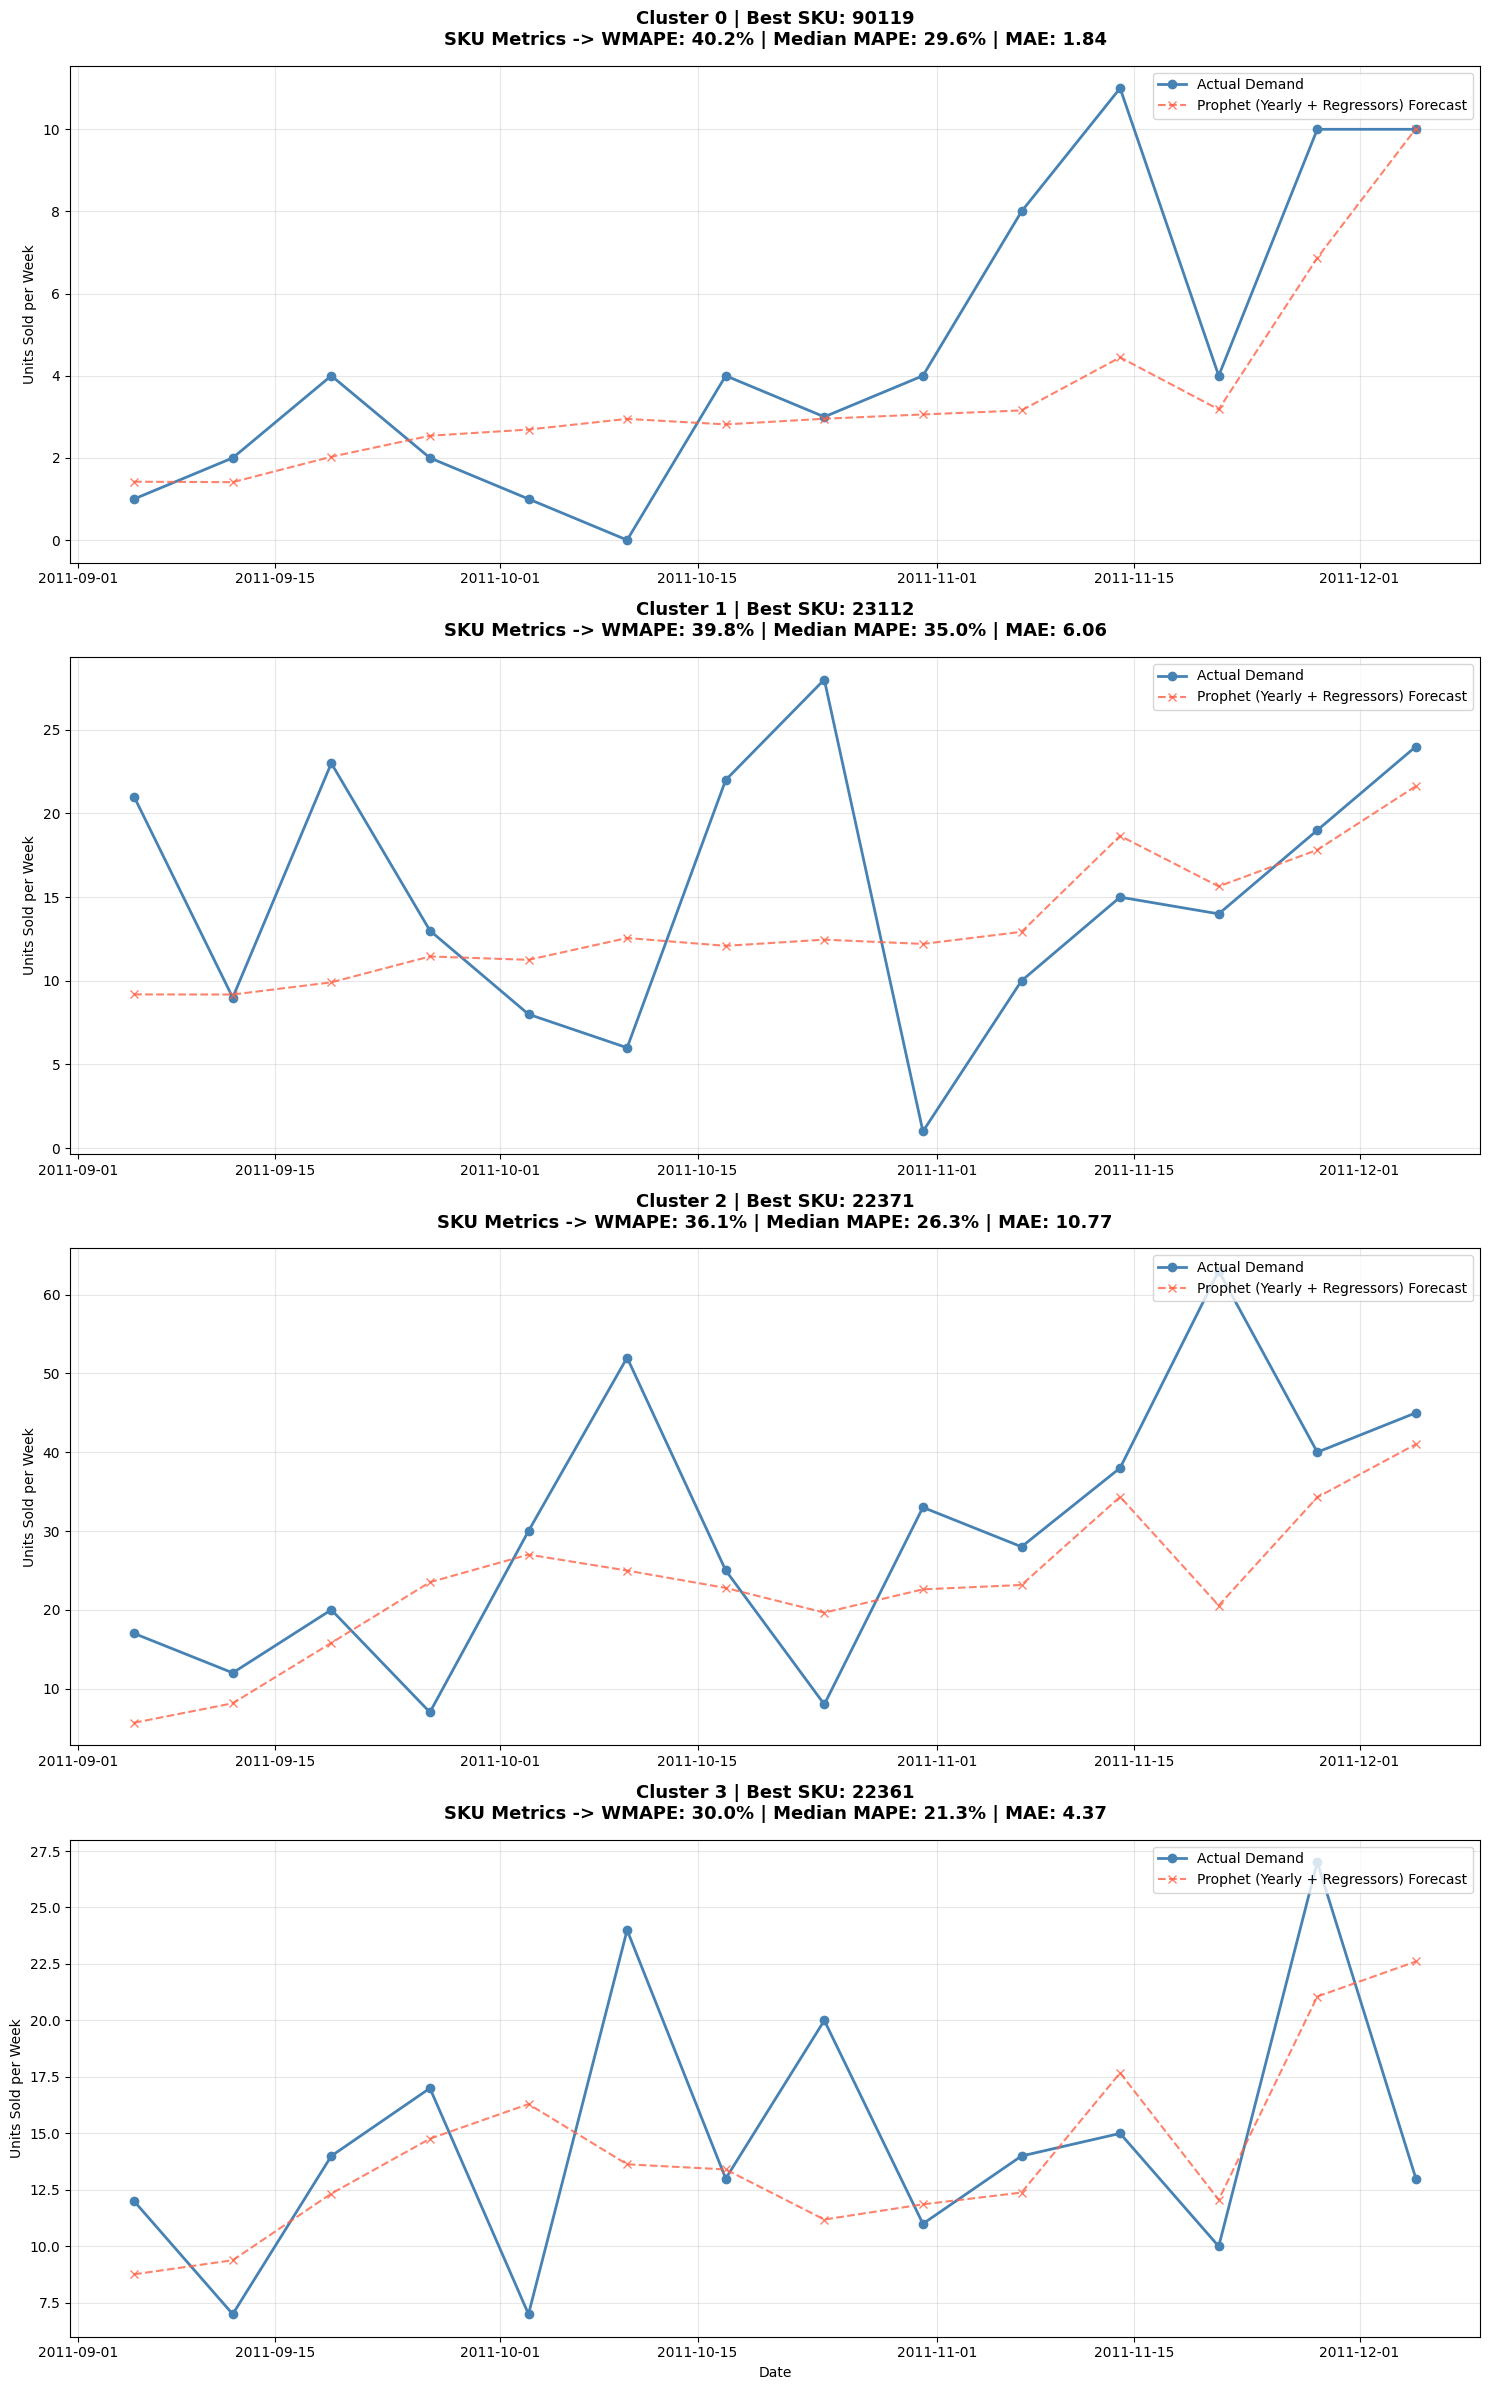

/Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/src/tools/visualization.py:188: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sku_metrics = cluster_eval.groupby("StockCode", observed=True).apply(calc_sku_metrics).dropna()
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning:

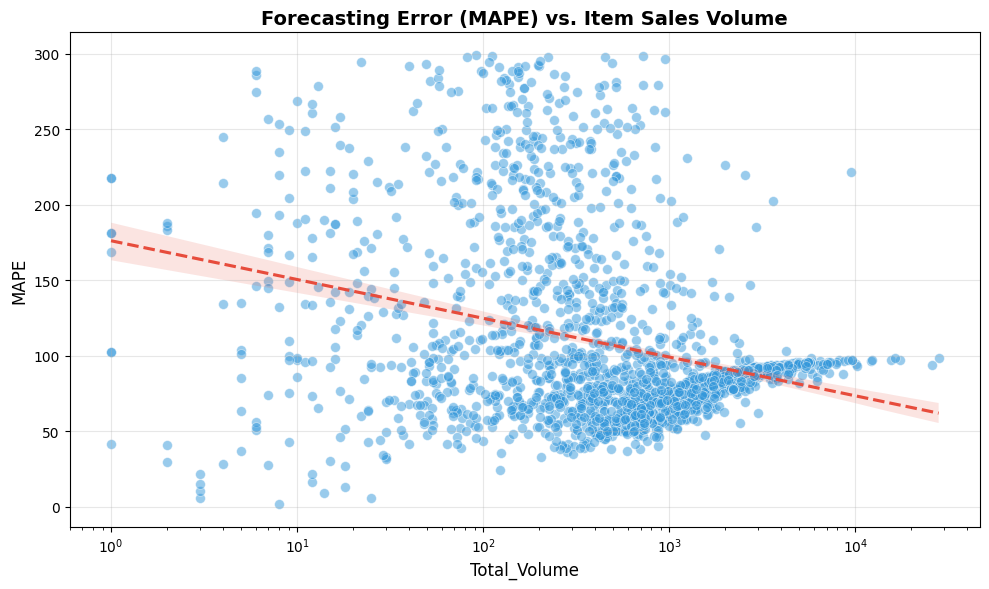

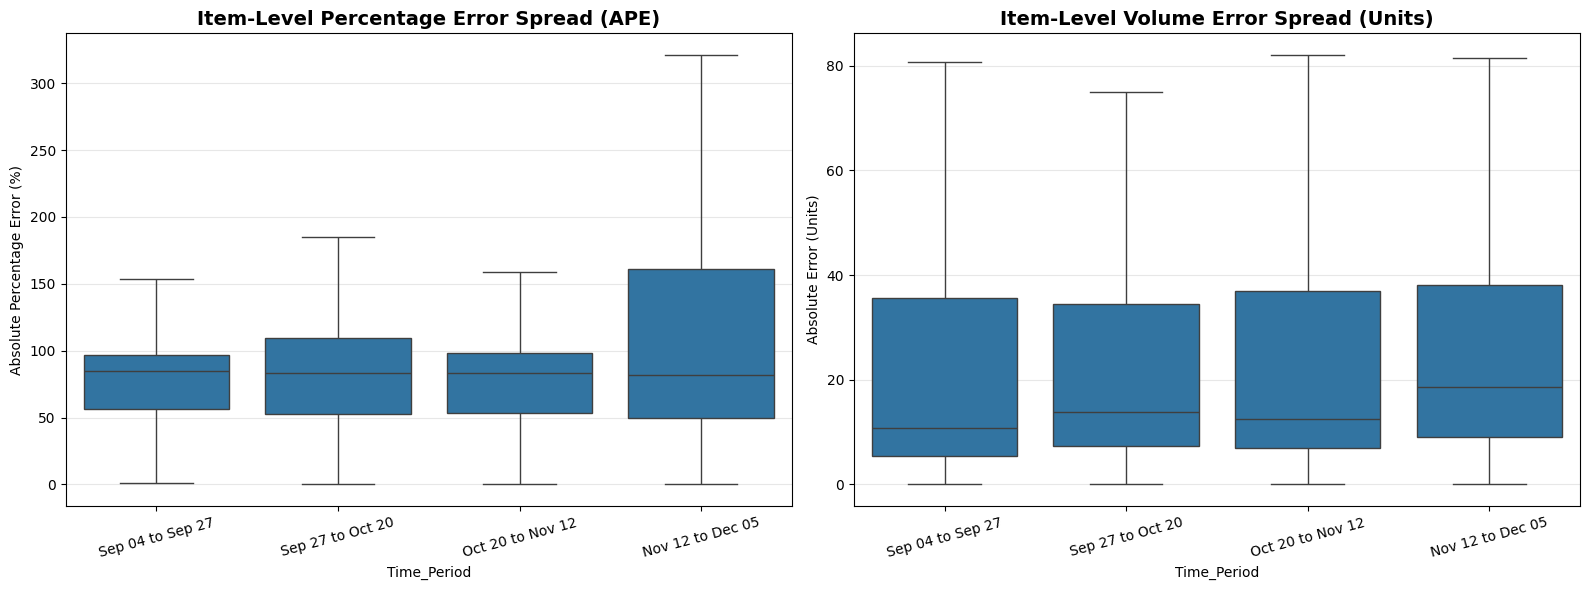

,WMAPE,Median_MAPE,Mean_Absolute_Error
Time_Period,,,
Sep 04 to Sep 27,95.61,84.56,47.00
Sep 27 to Oct 20,95.61,83.19,49.42
Oct 20 to Nov 12,95.17,83.46,55.64
Nov 12 to Dec 05,96.15,82.00,56.05


In [24]:
plot_cluster_portfolio(cluster_eval, summary, model_label="Prophet (Yearly + Regressors)")
plot_mape_vs_volume(cluster_eval)

# Analyze the drift of error over time
analyze_time_periods(test_raw)
